In [78]:
import warnings
warnings.filterwarnings(action='ignore')

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv('titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [6]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [8]:
# Seperate X and y
X, y = df.iloc[:,0:-1], df.iloc[:,-1]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
print(f'X_train: {X_train.shape} X_test: {X_test.shape}')

X_train: (712, 3) X_test: (179, 3)


In [23]:
X_train.isnull().mean()*100

Age       19.662921
Fare       5.056180
Family     0.000000
dtype: float64

In [27]:
mean_age, median_age = X_train['Age'].mean(), X_train['Age'].median()
mean_fare, median_fare = X_train['Fare'].mean(), X_train['Fare'].median()

## Using Numpy

In [36]:
# Imputing missing values by Mean/Median
X_train['Mean_Age'] = X_train['Age'].fillna(mean_age)
X_train['Median_Age'] = X_train['Age'].fillna(median_age)


X_train['Mean_Fare'] = X_train['Fare'].fillna(mean_fare)
X_train['Median_Fare'] = X_train['Fare'].fillna(median_fare)

In [37]:
X_train

,Age,Fare,Family,Mean_Age,Median_Age,Mean_Fare,Median_Fare
331,45.5,28.5000,0,45.500000,45.5,28.500000,28.5000
733,23.0,13.0000,0,23.000000,23.0,13.000000,13.0000
382,32.0,7.9250,0,32.000000,32.0,7.925000,7.9250
704,26.0,7.8542,1,26.000000,26.0,7.854200,7.8542
813,6.0,31.2750,6,6.000000,6.0,31.275000,31.2750
...,...,...,...,...,...,...,...
106,21.0,7.6500,0,21.000000,21.0,7.650000,7.6500
270,NaN,31.0000,0,29.498846,28.0,31.000000,31.0000
860,41.0,NaN,2,41.000000,41.0,32.517788,14.4000
435,14.0,120.0000,3,14.000000,14.0,120.000000,120.0000


In [44]:
# Checking change in Variance
print(f'Original Age Variance: {X_train['Age'].var()}')
print(f'Age Variance After Mean Imputation : {X_train['Mean_Age'].var()}')
print(f'Age Variance After Median Imputation: {X_train['Median_Age'].var()}')
print('-'*50)
print(f'Original Fare Variance: {X_train['Fare'].var()}')
print(f'Fare Variance After Mean Imputation : {X_train['Mean_Fare'].var()}')
print(f'Fare Variance After Median Imputation: {X_train['Median_Fare'].var()}')

Original Age Variance: 210.2517072477435
Age Variance After Mean Imputation : 168.85193366872227
Age Variance After Median Imputation: 169.20731007048155
--------------------------------------------------
Original Fare Variance: 2761.0314349486343
Fare Variance After Mean Imputation : 2621.232374951235
Fare Variance After Median Imputation: 2637.012481677765


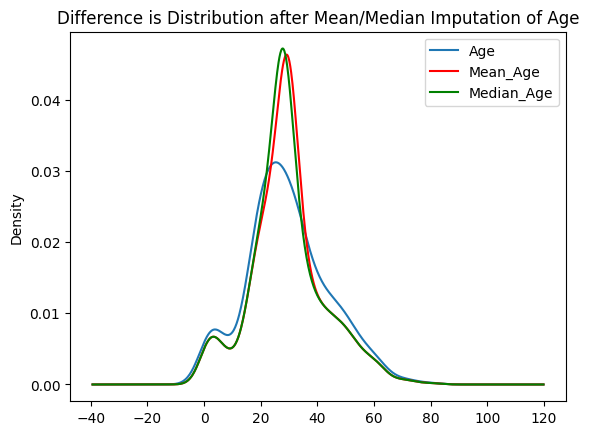

In [55]:
fig = plt.figure()
ax = fig.add_subplot(111)
plt.title('Difference in Distribution after Mean/Median Imputation of Age')
X_train['Age'].plot.density(ax=ax)

X_train['Mean_Age'].plot.density(ax=ax, color='red')

X_train['Median_Age'].plot.density(ax=ax, color='green')

plt.legend()
plt.show()

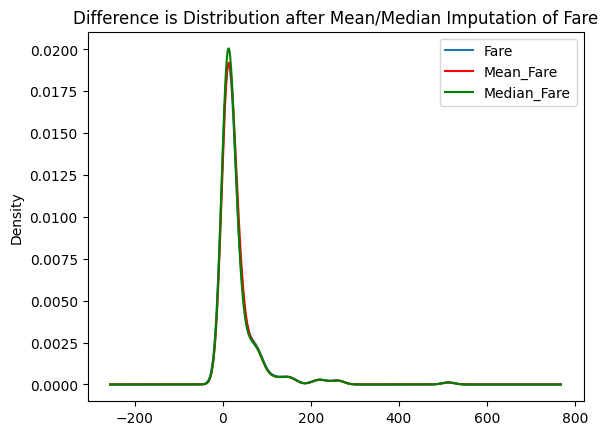

In [56]:
fig = plt.figure()
ax = fig.add_subplot(111)
plt.title('Difference is Distribution after Mean/Median Imputation of Fare')
X_train['Fare'].plot.density(ax=ax)

X_train['Mean_Fare'].plot.density(ax=ax, color='red')

X_train['Median_Fare'].plot.density(ax=ax, color='green')

plt.legend()
plt.show()

In [57]:
X_train.cov()

,Age,Fare,Family,Mean_Age,Median_Age,Mean_Fare,Median_Fare
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,71.193767,70.082085
Fare,75.481375,2761.031435,18.599163,60.224654,63.938058,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.616299,-5.587710,17.657433,17.672035
Mean_Age,210.251707,60.224654,-5.616299,168.851934,168.851934,57.175304,56.282518
Median_Age,210.251707,63.938058,-5.587710,168.851934,169.207310,60.700688,59.728510
Mean_Fare,71.193767,2761.031435,17.657433,57.175304,60.700688,2621.232375,2621.232375
Median_Fare,70.082085,2761.031435,17.672035,56.282518,59.728510,2621.232375,2637.012482


In [58]:
X_train.corr()

,Age,Fare,Family,Mean_Age,Median_Age,Mean_Fare,Median_Fare
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.088944,0.087232
Fare,0.091482,1.000000,0.207193,0.088151,0.093496,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.256883,-0.255307,0.204981,0.204536
Mean_Age,1.000000,0.088151,-0.256883,1.000000,0.998949,0.085941,0.084346
Median_Age,1.000000,0.093496,-0.255307,0.998949,1.000000,0.091145,0.089416
Mean_Fare,0.088944,1.000000,0.204981,0.085941,0.091145,1.000000,0.997003
Median_Fare,0.087232,1.000000,0.204536,0.084346,0.089416,0.997003,1.000000


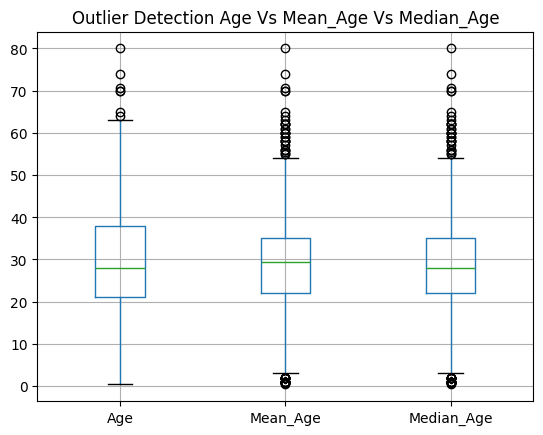

In [69]:
plt.title('Outlier Detection Age Vs Mean_Age Vs Median_Age')
X_train[['Age', 'Mean_Age', 'Median_Age']].boxplot()
plt.show()

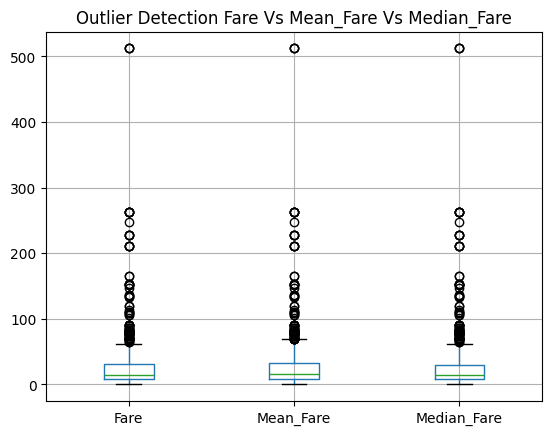

In [70]:
plt.title('Outlier Detection Fare Vs Mean_Fare Vs Median_Fare')
X_train[['Fare', 'Mean_Fare', 'Median_Fare']].boxplot()
plt.show()

## Using Sklearn's SimpleImputer

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
mean_imputer, median_imputer = SimpleImputer(strategy='mean'), SimpleImputer(strategy='median')

In [79]:
trf = ColumnTransformer([
    ('mean_imputer', mean_imputer, ['Age']),
    ('median_imputer', median_imputer, ['Fare'])
], remainder='passthrough')

In [80]:
trf.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('mean_imputer', SimpleImputer(), ['Age']),
                                ('median_imputer',
                                 SimpleImputer(strategy='median'), ['Fare'])])

In [89]:
mean_value_of_Age = trf.named_transformers_['mean_imputer'].statistics_
median_value_of_Fare = trf.named_transformers_['median_imputer'].statistics_

print('Mean Value of Age: ', mean_value_of_Age)
print('Media Value of Fare: ', median_value_of_Fare)

Mean Value of Age:  [29.49884615]
Media Value of Fare:  [14.4]


In [90]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [91]:
X_train

array([[ 45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  13.    ,   0.    ],
       [ 32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    ,  14.4   ,   2.    ],
       [ 14.    , 120.    ,   3.    ],
       [ 21.    ,  77.2875,   1.    ]], shape=(712, 3))

In [92]:
X_test

array([[ 29.49884615,  15.2458    ,   2.        ],
       [ 31.        ,  10.5       ,   0.        ],
       [ 20.        ,   7.925     ,   0.        ],
       [  6.        ,  33.        ,   1.        ],
       [ 14.        ,  11.2417    ,   1.        ],
       [ 26.        ,  78.85      ,   0.        ],
       [ 29.49884615,   7.75      ,   0.        ],
       [ 16.        ,  18.        ,   2.        ],
       [ 16.        ,   7.75      ,   0.        ],
       [ 19.        ,  26.2833    ,   2.        ],
       [ 37.        ,  53.1       ,   1.        ],
       [ 44.        ,   8.05      ,   0.        ],
       [ 29.49884615,  25.4667    ,   4.        ],
       [ 30.        ,   7.225     ,   0.        ],
       [ 36.        ,  13.        ,   0.        ],
       [ 16.        ,  39.4       ,   1.        ],
       [ 42.        ,  52.5542    ,   1.        ],
       [ 29.49884615,   7.8292    ,   0.        ],
       [ 27.        ,  13.        ,   0.        ],
       [ 47.        ,  52.     